In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from numpy import cos,pi,sqrt,log10
from astropy.table import Table
from astropy.table import unique
import os
import ctadata
from astropy.io import ascii
from scipy import stats
from scipy.optimize import curve_fit


In [2]:
data_folder = "./LST_data/"
DL3_folder = "/pnfs/cta.cscs.ch/lst/DL3/"
run_catalog=ascii.read(data_folder + 'LST_source_catalog.ecsv')

In [3]:
e_bins=np.array([0.5, 1.5, 4.0, 10.0, 25.0])
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0.0, 0.13, 20)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

In [10]:
def find_and_process_files(runlist, gheff, 
                          ra_obj, dec_obj, bkg_subtraction_radius,
                          e_mins, e_maxs, e, th2_bins,
                          cts_s, cts_b, cts_effarea_corr, cts_effarea_corr_err,
                          t_expo, flist, counter, ind):
    # CAREFUL: cts_effarea_corr_err is the error squared
    # remember to to cts_effarea_corr_err = np.sqrt(cts_effarea_corr_err) after this func call.
    counter = 0
    for ind in range(len(runlist)):
        r = runlist[ind]
        for i in range(len(run_catalog)):
            run = run_catalog[i]['Run ID']
            if run == r:
                date = run_catalog[i]['Date directory'].replace('-', '')
                vers = ctadata.list_dir(DL3_folder + date)
                for ver in vers:
                    if ver[0] == 'v':
                        tailcuts = ctadata.list_dir(DL3_folder + date + '/' + ver)
                        for tailcut in tailcuts:
                            nsbs = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut)
                            for nsb in nsbs:
                                versions = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb)
                                for version in versions:
                                    tags = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std')
                                    for tag in tags:
                                        src_dependences = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag)
                                        for src_dep in src_dependences:
                                            point_or_full = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep)
                                            for p_f in point_or_full:
                                                wobbles = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f)
                                                for wob in wobbles:
                                                    gheffs = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f + '/' + wob)
                                                    for gh in gheffs:
                                                        if gheff in gh:
                                                            irfs = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f + '/' + wob + '/' + gh)
                                                            for irf in irfs:
                                                                files = ctadata.list_dir(DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f + '/' + wob + '/' + gh + '/' + irf)
                                                                
                                                                if run < 10000:
                                                                    fname = 'dl3_LST-1.Run0' + str(run) + '.fits'
                                                                else:
                                                                    fname = 'dl3_LST-1.Run' + str(run) + '.fits'
                                                                
                                                                if fname in files:
                                                                    file_path = DL3_folder + date + '/' + ver + '/' + tailcut + '/' + nsb + '/' + version + '/std/' + tag + '/' + src_dep + '/' + p_f + '/' + wob + '/' + gh + '/' + irf + '/' + fname
                                                                    flist.append(file_path)
                                                                    ctadata.fetch_and_save_file_or_dir(file_path)
                                                                    
                                                                    with fits.open(fname) as hdul:
                                                                        header = hdul[1].header
                                                                        dat = header['DATE-OBS']
                                                                        t_expo += header['LIVETIME']
                                                                        print(ind, date, fname, header['LIVETIME'])
                                                                        
                                                                        ra_pnt = header['RA_PNT']
                                                                        dec_pnt = header['DEC_PNT']
                                                                        dra = ra_obj - ra_pnt
                                                                        ddec = dec_obj - dec_pnt
                                                                        
                                                                        ra_bkg = ra_pnt - dra
                                                                        dec_bkg = dec_pnt - ddec
                                                                        coords_bkg = SkyCoord(ra_bkg, dec_bkg, unit='degree')
                                                                        coords_obj = SkyCoord(ra_obj, dec_obj, unit='degree')
                                                                        
                                                                        events = hdul['EVENTS'].data
                                                                        coords = SkyCoord(events['RA'], events['DEC'], unit='degree')
                                                                        
                                                                        seps = coords.separation(coords_obj).deg
                                                                        seps_b = coords.separation(coords_bkg).deg
                                                                        energies = events['ENERGY']
                                                                        
                                                                        effarea_hdu = hdul['EFFECTIVE AREA'].data
                                                                        effarea = effarea_hdu["EFFAREA"] * 100**2
                                                                        effareas_ebins_mean = np.sqrt(effarea_hdu["ENERG_LO"] * effarea_hdu["ENERG_HI"])
                                                                        
                                                                        for i in range(len(e)):
                                                                            m_s = (energies > e_mins[i]) * (energies < e_maxs[i]) * (seps < bkg_subtraction_radius)
                                                                            h_s = np.histogram(seps[m_s]**2, bins=th2_bins)
                                                                            cts_s[i] += h_s[0]
                                                                            
                                                                            m_b = (energies > e_mins[i]) * (energies < e_maxs[i]) * (seps_b < bkg_subtraction_radius)
                                                                            h_b = np.histogram(seps_b[m_b]**2, bins=th2_bins)
                                                                            cts_b[i] += h_b[0]
                                                                            
                                                                            diff = h_s[0] - h_b[0]
                                                                            diff_err = np.sqrt(h_s[0] + h_b[0])
                                                                            effarea_usable_ind = np.argmin(np.abs(e[i] * np.ones(effareas_ebins_mean.shape[0]) - effareas_ebins_mean))
                                                                            cts_effarea_corr[i] += diff / effarea[0][0][effarea_usable_ind]
                                                                            cts_effarea_corr_err[i] += (diff_err / effarea[0][0][effarea_usable_ind]) ** 2
                                                                    
                                                                    os.remove(fname)
                                                                    counter += 1
                                                                    if counter >= countermax:
                                                                        return cts_s, cts_b, cts_effarea_corr, cts_effarea_corr_err, t_expo
    
    return cts_s, cts_b, cts_effarea_corr, cts_effarea_corr_err, t_expo

**CRAB spectrum, PSF model**

In [11]:
Name='Crab'
gheff='gheff0.9'
Zdcut=30

coords_obj=SkyCoord.from_name(Name)
ra_obj=coords_obj.icrs.ra.deg
dec_obj=coords_obj.icrs.dec.deg
ra_obj,dec_obj
cdec=cos(dec_obj*pi/180.)
ra_obj,dec_obj

(83.6324, 22.0174)

In [12]:
runlist = np.load(data_folder + 'good_runs_' + Name + '_Zd_30.0.npy')
countermax = 10
bkg_subtraction_radius = 0.4

cts_s = np.zeros((len(e), len(th2)))
cts_b = np.zeros((len(e), len(th2)))
cts_effarea_corr = np.zeros((len(e), len(th2)))
cts_effarea_corr_err = np.zeros((len(e), len(th2)))

t_expo = 0

cts_s, cts_b, cts_effarea_corr, cts_effarea_corr_err, t_expo = find_and_process_files(
    runlist=runlist,
    gheff=gheff,
    ra_obj=ra_obj,
    dec_obj=dec_obj,
    bkg_subtraction_radius=bkg_subtraction_radius,
    e_mins=e_mins,
    e_maxs=e_maxs,
    e=e,
    th2_bins=th2_bins,
    cts_s=cts_s,
    cts_b=cts_b,
    cts_effarea_corr=cts_effarea_corr,
    cts_effarea_corr_err=cts_effarea_corr_err,
    t_expo=t_expo,
    flist=flist,
    counter=counter,
    ind=ind
)

cts_effarea_corr_err = np.sqrt(cts_effarea_corr_err)
print(f"Total exposure: {t_expo/3600}h")

0 20200913 dl3_LST-1.Run02692.fits 795.7776004104894
1 20201118 dl3_LST-1.Run02929.fits 1006.0123373972738
2 20201118 dl3_LST-1.Run02930.fits 1107.1882837177604
3 20201118 dl3_LST-1.Run02931.fits 1097.356265673436
4 20201118 dl3_LST-1.Run02932.fits 1096.1565143582543
5 20201118 dl3_LST-1.Run02933.fits 1109.3478662613109
6 20201118 dl3_LST-1.Run02934.fits 1109.300005536095
7 20201119 dl3_LST-1.Run02949.fits 1143.8056892959899
8 20201119 dl3_LST-1.Run02950.fits 1166.1911191647434
9 20201119 dl3_LST-1.Run02956.fits 1090.0646574511518
Total exposure: 2.978111205351807h


In [15]:
fluxes = e**2*cts_effarea_corr.T/t_expo/de
fluxes_err = e**2*cts_effarea_corr_err.T/t_expo/de
fluxes=fluxes.T
fluxes_err=fluxes_err.T

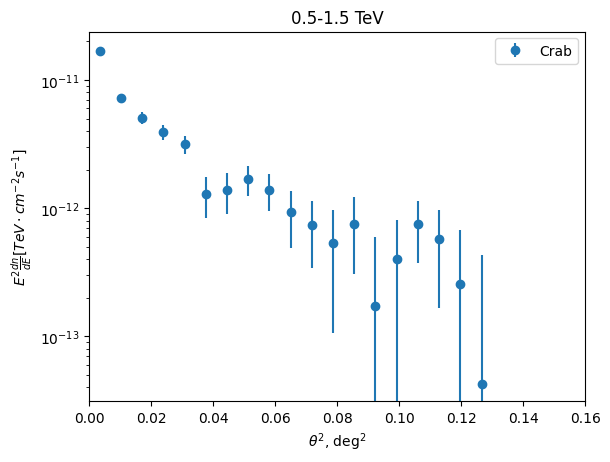

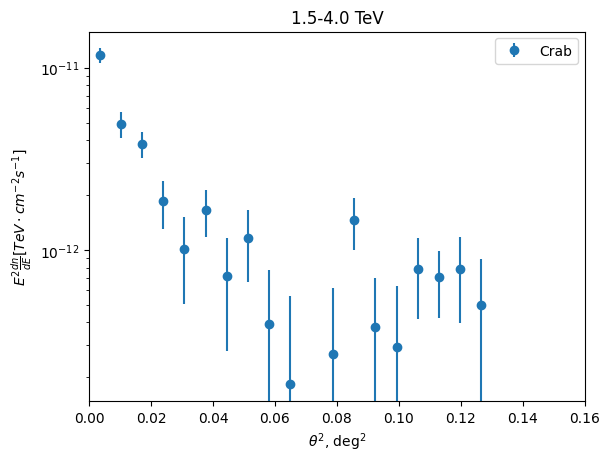

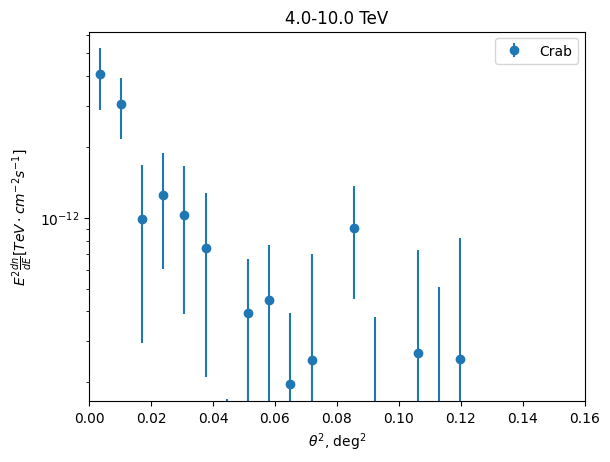

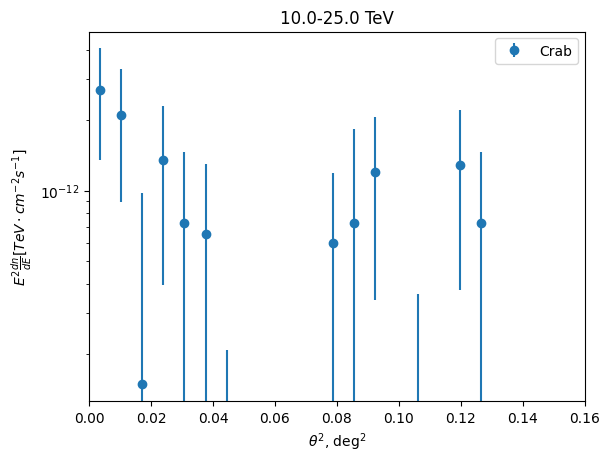

In [19]:
for i in range(fluxes.shape[0]):
    plt.figure()
    plt.errorbar(th2,fluxes[i],fluxes_err[i],linestyle='none',marker='o',label=Name)
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$E^2 \frac{dn}{dE} [TeV \cdot cm^{-2} s^{-1}]$')
    plt.legend(loc='upper right')
    plt.yscale("log")
    plt.show()

In [27]:
def double_gaussian(th2, norm1, norm2, sigma1, sigma2):
    gauss1 = norm1 * np.exp(-th2 / (2 * sigma1**2))
    gauss2 = norm2 * np.exp(-th2 / (2 * sigma2**2))
    return gauss1 + gauss2

In [29]:
init_guess = [1.0, 1.0, 0.1, 0.5]

for i, (flux, flux_err) in enumerate(zip(fluxes, fluxes_err)):
    try:
        popt, pcov = curve_fit(
            double_gaussian,
            th2,
            flux,
            sigma=flux_err,
            p0=init_guess,
            absolute_sigma=True,
            maxfev=5000,
        )
        norm1, norm2, sigma1, sigma2 = popt
        norm1_err, norm2_err, sigma1_err, sigma2_err = np.sqrt(np.diag(pcov))

        print(rf"$E \in [{e_mins[i]}, {e_maxs[i]}]$:")
        print(rf"Gaussian 1: $\sigma = {sigma1:.3f} \pm {sigma1_err:.3f}, Norm = {norm1} \pm {norm1_err}$")
        print(rf"Gaussian 2: $\sigma = {sigma2:.3f} \pm {sigma2_err:.3f}, Norm = {norm2} \pm {norm2_err}$")
        print("\n")
        
    except Exception as e:
        print(f"Fit failed for energy bin {i}: {e}")
        print("\n")

$E \in [0.5, 1.5]$:
Gaussian 1: $\sigma = 0.047 \pm 0.007, Norm = 2.2383994387904345e-11 \pm 4.309675592731296e-12$
Gaussian 2: $\sigma = 0.126 \pm 0.010, Norm = 7.339409436458243e-12 \pm 1.6103349786692305e-12$


$E \in [1.5, 4.0]$:
Gaussian 1: $\sigma = 0.071 \pm 0.006, Norm = 1.478199473231906e-11 \pm 1.8294680740775866e-12$
Gaussian 2: $\sigma = 317.957 \pm 176178393.295, Norm = 5.329568561945859e-13 \pm 4.3801909537652054e-13$


$E \in [4.0, 10.0]$:
Gaussian 1: $\sigma = 0.103 \pm 0.030, Norm = 4.32653321697417e-12 \pm 1.1174941280132048e-12$
Gaussian 2: $\sigma = 188.932 \pm 367537026.068, Norm = -8.780127802628295e-14 \pm 9.27746644384288e-13$


$E \in [10.0, 25.0]$:
Gaussian 1: $\sigma = 0.100 \pm inf, Norm = 1.0 \pm inf$
Gaussian 2: $\sigma = 0.500 \pm inf, Norm = 1.0 \pm inf$




/tmp/ipykernel_19598/1696442431.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(
